<a href="https://colab.research.google.com/github/Levi-003/AI-training-Tasks/blob/main/adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


In [ ]:
df = pd.read_csv("UCI_Credit_Card.csv")

In [ ]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0 

In [ ]:
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

X = X.drop("ID", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
base_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_model,
    random_state=42
)

In [ ]:
base_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_model,
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.1, 1.0]
}

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    ada_model,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1, #Use all available CPU cores to speed up the search.
    verbose=2 #how much progress information is printed while the search is running
)
grid.fit(X_train, y_train)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                           random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 1.0],
                         'n_estimators': [50, 100]},
             scoring='roc_auc', verbose=2)

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best Parameters: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV ROC-AUC: 0.7717578806575669


In [ ]:
model = grid.best_estimator_

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8171666666666667
Accuracy (%): 81.71666666666667


[[4461  212]
 [ 885  442]]


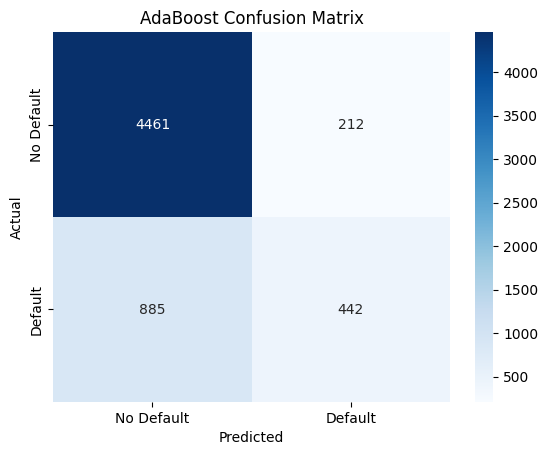

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")
plt.show()

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7685902161094431


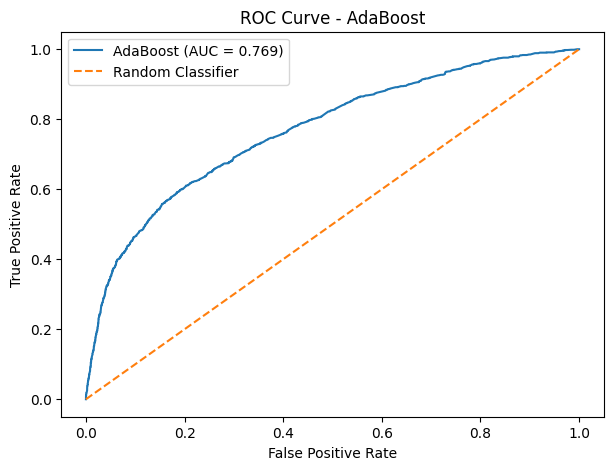

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AdaBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend()
plt.show()